# TV Ratings Analysis & Forecasting

## Project Goal

This project analyzes morning TV audience ratings to identify relevant audience patterns, evaluate potential drivers of rating changes, and build a forecasting model to support programming decisions.

The goal is not only to predict ratings, but also to translate data into business insights that can help a TV channel make better content and scheduling decisions.

## 1. Business Context

TV channels compete for audience attention every day. Understanding how ratings change over time, how competitors behave, and how on-screen presence affects audience performance can support better programming decisions.

This analysis focuses on three main questions:

1. How do TV ratings behave over time?
2. Which factors appear to influence rating changes?
3. Can we forecast future rating performance using historical data?

## 2. Import Libraries

In [58]:
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (14,4)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

## 3. Load Data
### 3.1 Ratings Dataset

In [59]:
df = pd.read_excel(r"C:\Users\jtahu\OneDrive\Escritorio\Github\data\tv rating.xlsx")
df['FechaHora'] = pd.to_datetime(df['Fecha'].astype(str) + ' ' + df['Hora'].astype(str))

# Dataframe filtered so it shows only the program's time slot
df = df[(df['FechaHora'].dt.time >= pd.Timestamp('08:00:00').time()) &
        (df['FechaHora'].dt.time <= pd.Timestamp('13:00:00').time())]

### 3.2 On-screen presence Dataset

In [60]:
tiempo_rostros = pd.read_excel(r"C:\Users\jtahu\OneDrive\Escritorio\Github\data\on screen presence.xlsx", index_col=0)
tiempo_rostros = tiempo_rostros["2022-01-03":]
tiempo_rostros.head()

,Duración,Tiempo_rostros,Tiempo_rostros_sinsuperposición,Porcentaje_rostros_pantalla,TamaraA,MiguelA,LoretoA,AngelesA,CarolinaA,PazB,...,FranciscoS,MirnaS,EmilioS,MariaES,TonkaT,SebastianU,IvanV,GonzaloV,PriscillaV,JorgeZ
Fecha,,,,,,,,,,,,,,,,,,,,,
2022-01-03,262.83,306.35,176.85,0.672868,0,0.0,0.0,133.02,0.0,0.0,...,8.83,123.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.42
2022-01-04,238.40,219.27,137.00,0.574664,0,0.0,0.0,98.23,0.0,0.0,...,0.00,107.20,6.2,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2022-01-05,258.78,247.55,156.28,0.603911,0,0.0,0.0,120.40,0.0,0.0,...,0.00,112.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2022-01-06,259.60,284.92,177.35,0.683166,0,0.0,0.0,115.37,0.0,0.0,...,0.00,119.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2022-01-07,259.13,136.59,101.23,0.390653,0,0.0,0.0,80.87,0.0,0.0,...,0.00,55.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


## 4. Data Overview
### 4.1 Ratings variables

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109865 entries, 480 to 524940
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Fecha      109865 non-null  datetime64[ns]
 1   Hora       109865 non-null  object        
 2   chv        109865 non-null  float64       
 3   red        109865 non-null  float64       
 4   mega       109865 non-null  float64       
 5   tvn        109865 non-null  float64       
 6   c13        109865 non-null  float64       
 7   ucv        109865 non-null  float64       
 8   tc         109865 non-null  float64       
 9   cable      109865 non-null  float64       
 10  hogar      109865 non-null  float64       
 11  FechaHora  109865 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(9), object(1)
memory usage: 10.9+ MB


In [62]:
df.describe()

,Fecha,chv,red,mega,tvn,c13,ucv,tc,cable,hogar,FechaHora
count,109865,109865.000000,109865.000000,109865.000000,109865.000000,109865.000000,109865.000000,109865.000000,109865.000000,109865.000000,109865
mean,2022-07-02 00:00:00,6.608472,0.254601,5.685114,3.295979,3.570417,0.264933,0.065474,8.041395,30.698240,2022-07-02 10:30:00
min,2022-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.065700,0.000000,0.000000,0.858900,8.596100,2022-01-01 08:00:00
25%,2022-04-02 00:00:00,5.235500,0.000000,4.803400,2.517500,2.697000,0.065300,0.000000,5.664600,27.043900,2022-04-02 09:15:00
50%,2022-07-02 00:00:00,6.877300,0.186900,5.809800,3.292200,3.479600,0.227500,0.000000,7.485100,32.044000,2022-07-02 10:30:00
75%,2022-10-01 00:00:00,8.227300,0.398400,6.713400,4.075600,4.356300,0.410200,0.139500,9.860900,35.158200,2022-10-01 11:45:00
max,2022-12-31 00:00:00,27.330900,3.575800,11.825700,12.816900,18.331500,2.886300,2.592400,25.084500,64.315700,2022-12-31 13:00:00
std,NaN,2.357582,0.279464,1.565609,1.192100,1.339584,0.251577,0.126671,3.142019,6.815614,NaN


There are no missing values for any of the variables.

### Ratings Dataset Description

The dataset contains audience rating per minute information from some of the streamed chilean channels.

Key variables used in the analysis:

- `FechaHora` : time variable which will be used later to do data preparation.
- `chv` : audience rating regarding "Chilevisión" channel.
- `mega` : audience rating regarding "Megavisión" channel.
- `tvn` : audience rating regarding "Televisión Nacional" channel.
- `c13` : audience rating regarding "Canal 13" channel.

### 4.2 On-screen presence variables

In [63]:
tiempo_rostros.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 260 entries, 2022-01-03 to 2022-12-30
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Duración                         260 non-null    float64
 1   Tiempo_rostros                   260 non-null    float64
 2   Tiempo_rostros_sinsuperposición  260 non-null    float64
 3   Porcentaje_rostros_pantalla      260 non-null    float64
 4   TamaraA                          260 non-null    int64  
 5   MiguelA                          260 non-null    float64
 6   LoretoA                          260 non-null    float64
 7   AngelesA                         260 non-null    float64
 8   CarolinaA                        260 non-null    float64
 9   PazB                             260 non-null    float64
 10  FelipeB                          260 non-null    float64
 11  CristianC                        260 non-null    float64
 12  Mar

In [64]:
tiempo_rostros.describe()

,Duración,Tiempo_rostros,Tiempo_rostros_sinsuperposición,Porcentaje_rostros_pantalla,TamaraA,MiguelA,LoretoA,AngelesA,CarolinaA,PazB,...,FranciscoS,MirnaS,EmilioS,MariaES,TonkaT,SebastianU,IvanV,GonzaloV,PriscillaV,JorgeZ
count,260.000000,260.000000,260.000000,260.000000,260.0,260.000000,260.000000,260.000000,260.000000,260.00000,...,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,256.454861,244.588606,154.968725,0.609569,0.0,0.151554,0.033944,55.131514,0.060518,0.00012,...,2.248486,61.450279,5.760757,0.002390,0.413466,8.608845,0.341355,0.025339,46.161952,1.458685
std,32.236918,133.451362,50.904177,0.194947,0.0,0.806254,0.395175,50.155765,0.714673,0.00186,...,11.199827,48.480344,9.046355,0.037208,3.227464,15.821043,2.218694,0.392540,87.603306,9.594273
min,55.180000,12.980000,13.000000,0.047710,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,256.855000,158.465000,122.632500,0.491126,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,258.780000,201.600000,149.960000,0.579144,0.0,0.000000,0.000000,57.820000,0.000000,0.00000,...,0.000000,66.585000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,264.772500,271.392500,177.567500,0.696386,0.0,0.000000,0.000000,92.382500,0.000000,0.00000,...,0.000000,95.455000,8.927500,0.000000,0.000000,10.692500,0.000000,0.000000,11.457500,0.000000
max,305.500000,716.880000,272.170000,0.999174,0.0,7.180000,5.750000,200.380000,11.250000,0.03000,...,120.180000,187.320000,65.630000,0.600000,43.420000,101.970000,19.850000,6.330000,250.920000,113.620000


There are no missing values in the dataset.

### On-screen presence Dataset Description

The dataset contains screen time information regarding people who participate and appear in the program.

Key variables used in the analysis:

- `Tiempo_rostros` : total time recorded in which at least one person is on screen.
- character's name: proportion of total daily screen time from a character relative to the total duration of the episode.

## 5. Data Cleaning & Preparation

### 5.1 Cleaning rating data

Since there are no missing or outlier values in the database, the following steps were taken to better support the business analysis:

#### (a) Elimination of irrelevant information

In addition to the rating itself, the company deemed it important to consider only the viewership of its main competitors (CHV, MEGA, TVN). The others were excluded.

In [65]:
df = df[["Fecha", "chv", "mega", "tvn", "c13", "FechaHora"]]

#### (b) Computing the daily average rating

Since the data is displayed on a per-minute basis, it was decided to calculate the daily average rating for each channel to make the data easier to interpret, even though this results in some loss of information.

In [66]:
avg_chv = df.groupby(df['FechaHora'].dt.date)['chv'].mean()
avg_mega = df.groupby(df['FechaHora'].dt.date)['mega'].mean()
avg_tvn = df.groupby(df['FechaHora'].dt.date)['tvn'].mean()
avg_c13 = df.groupby(df['FechaHora'].dt.date)['c13'].mean()

#### (c) Elimination of days with no broadcast

Finally, the program aired only Monday through Friday, so Saturdays and Sundays were excluded from the analysis.

In [67]:
#Eliminates weekends
def eliminar_fds(canal):
    num_filas = len(canal)

    numeros = list(range(1, 8))

    repeticiones = num_filas // len(numeros)

    canal['Numeros'] = numeros * repeticiones + numeros[:num_filas % len(numeros)]
    
    canal = canal.loc[~canal['Numeros'].isin([1, 2])]
    canal = canal.drop(columns=["Numeros"])
        
    return canal

#CANAL 13
c13 = pd.DataFrame({"c13": avg_c13})
c13.index = pd.to_datetime(c13.index)
c13 = eliminar_fds(c13)

#MEGA
mega = pd.DataFrame({"mega": avg_mega})
mega.index = pd.to_datetime(mega.index)
mega = eliminar_fds(mega)

#CHV
chv = pd.DataFrame({"chv": avg_chv})
chv.index = pd.to_datetime(chv.index)
chv = eliminar_fds(chv)

#TVN
tvn = pd.DataFrame({"tvn": avg_tvn})
tvn.index = pd.to_datetime(tvn.index)
tvn = eliminar_fds(tvn)

### 5.2 Cleaning on-screen presence data

Similarly, there are no missing or outlier values in this database. Therefore, the following transformations were performed:

#### (a) Elimination of irrelevant information

Only each individual’s daily attendance in the program was relevant for this analysis.

In [68]:
tiempo_rostros = tiempo_rostros.drop(tiempo_rostros.columns[[0,2,3]], axis=1)
tiempo_rostros.head()

,Tiempo_rostros,TamaraA,MiguelA,LoretoA,AngelesA,CarolinaA,PazB,FelipeB,CristianC,MartinC,...,FranciscoS,MirnaS,EmilioS,MariaES,TonkaT,SebastianU,IvanV,GonzaloV,PriscillaV,JorgeZ
Fecha,,,,,,,,,,,,,,,,,,,,,
2022-01-03,306.35,0,0.0,0.0,133.02,0.0,0.0,0.0,0.0,0.0,...,8.83,123.10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.42
2022-01-04,219.27,0,0.0,0.0,98.23,0.0,0.0,0.0,0.0,0.0,...,0.00,107.20,6.2,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2022-01-05,247.55,0,0.0,0.0,120.40,0.0,0.0,0.0,0.0,0.0,...,0.00,112.55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2022-01-06,284.92,0,0.0,0.0,115.37,0.0,0.0,0.0,0.0,0.0,...,0.00,119.02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2022-01-07,136.59,0,0.0,0.0,80.87,0.0,0.0,0.0,0.0,0.0,...,0.00,55.62,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


#### (b) Grouping of variables

Three distinct types of groupings were performed: by subjects of interest; by the person’s gender; and by the television role they played in the program.

In [69]:
#Agrupation by relevant characters
personajes_interes = ['AngelesA', 'GianfrancoM', 'MirnaS', 'JoseLR', 'PriscillaV']

#Agrupation by gender
mujeres = ['TamaraA', 'LoretoA', 'AngelesA', 'CarolinaA', 'PazB', 'IngridC', 'BlancaL', 'NataliaL',
           'FranciscaM', 'MonicaP', 'MariaJP', 'TeresitaR', 'MirnaS', 'MariaES', 'TonkaT', 'PriscillaV']
hombres = ['MiguelA', 'FelipeB', 'CristianC', 'MartinC', 'SergioL', 'GianfrancoM', 'DanielM', 'DiegoM',
           'HectorN', 'RobertoP', 'PoloR', 'JoseLR', 'FranciscoS', 'EmilioS', 'SebastianU', 'IvanV', 'GonzaloV', 'JorgeZ']

#Agrupation by TV role
roles = {
    'Actors': ['TamaraA', 'LoretoA', 'CarolinaA','PazB', 'FelipeB', 'CristianC', 'IngridC',
                'BlancaL', 'FranciscaM', 'DanielM', 'DiegoM', 'HectorN', 'RobertoP', 'MariaJP', 'TeresitaR', 'MariaES', 'GonzaloV', 'JorgeZ'],
    'Hosts': ['AngelesA', 'MartinC', 'SergioL', 'JoseLR', 'FranciscoS', 'MirnaS', 'TonkaT', 'PriscillaV'],
    'Journalists': ['MiguelA', 'NataliaL', 'MonicaP','PoloR','EmilioS', "IvanV"],
    'Meteorologists': ['GianfrancoM'],
    'Doctors': ['SebastianU']
}

#### (c) Computing percentages

For each group of interest, the percentage of appearance was calculated in order to improve the interpretability of future results.

In [70]:
for personaje in personajes_interes:
    tiempo_rostros[f'{personaje}_porcentaje'] = (tiempo_rostros[personaje] / tiempo_rostros['Tiempo_rostros']) * 100

tiempo_rostros['Porcentaje_Mujeres'] = tiempo_rostros[mujeres].sum(axis=1) / tiempo_rostros['Tiempo_rostros'] * 100
tiempo_rostros['Porcentaje_Hombres'] = tiempo_rostros[hombres].sum(axis=1) / tiempo_rostros['Tiempo_rostros'] * 100

for rol, miembros in roles.items():
    tiempo_rostros[f'Porcentaje_{rol}'] = tiempo_rostros[miembros].sum(axis=1) / tiempo_rostros['Tiempo_rostros'] * 100

## 6. Exploratory Data Analysis

### 6.1 Rating Evolution Over Time

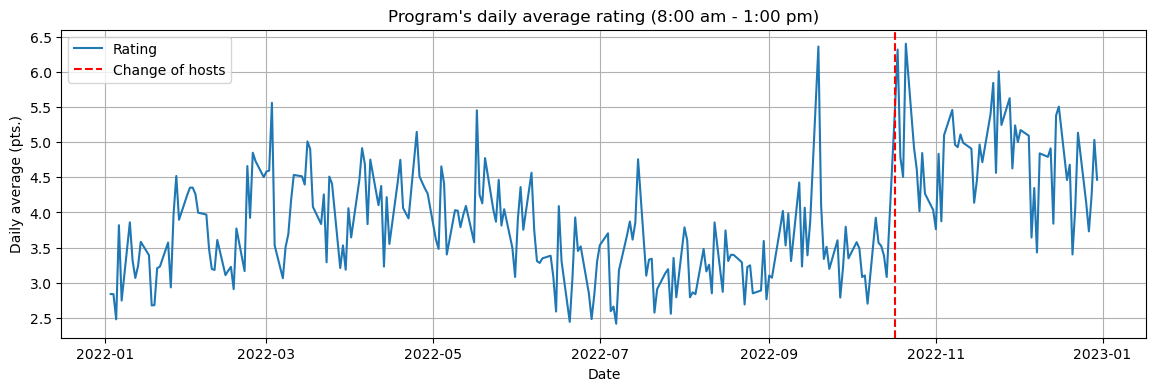

In [87]:
plt.plot(c13["c13"], label="Rating")
plt.axvline(x=pd.to_datetime('2022-10-17'), color='red', linestyle='--', label='Change of hosts')
plt.legend()
plt.grid()
plt.title("Program's daily average rating (8:00 am - 1:00 pm)")
plt.xlabel("Date")
plt.ylabel("Daily average (pts.)")
plt.savefig("Program's daily average rating.pdf", format="pdf")
plt.show()

The ratings in question do not appear to show any clear patterns or trends. However, additional information was available regarding a change in the show’s hosts, which took place on October 17, 2022.

#### (a) Analysis of the shift in ratings

In [72]:
c13["cambio"] = np.where(c13.index >= '2022-10-17', 1, 0) #Creación de variable dummy para simular cambio.

In [73]:
#Fitted model which studies the dummy variable.
print(f"Variable's coefficient: {smf.ols('c13 ~ cambio', c13).fit().params.iloc[1].round(4)} P-value: {smf.ols('c13 ~ cambio', c13).fit().pvalues.iloc[1].round(4)}")

Variable's coefficient: 1.1097 P-value: 0.0


This analysis suggested that the change in the show's hosts is significantly associated with an increase in ratings following that event. This could indicate that, on average, the audience finds these hosts more engaging than the previous ones.

#### (b) Stationarity analysis

In [74]:
print(adfuller(c13["c13"], regression = 'c')[1])

0.004210368061858809


Based on the results of this test, it was concluded that the rating exhibits stationarity.

#### (c) Stationality analysis

In [75]:
# Creation of dummy variables.
c13['d1'] = np.tile([1,0,0,0,0], len(c13) // 5 + 1)[:len(c13)]
c13['d2'] = np.tile([0,1,0,0,0], len(c13) // 5 + 1)[:len(c13)]
c13['d3'] = np.tile([0,0,1,0,0], len(c13) // 5 + 1)[:len(c13)]
c13['d4'] = np.tile([0,0,0,1,0], len(c13) // 5 + 1)[:len(c13)]
c13['d5'] = np.tile([0,0,0,0,1], len(c13) // 5 + 1)[:len(c13)]

#Fitted model which studies stationality.
print(f"Coeficiente variable 'd2': {smf.ols('c13 ~ cambio + d2 + d3 + d4 + d5', c13).fit().params.iloc[2].round(4)} P-value: {smf.ols('c13 ~ cambio + d2 + d3 + d4 + d5', c13).fit().pvalues.iloc[2].round(4)}")
print(f"Coeficiente variable 'd3': {smf.ols('c13 ~ cambio + d2 + d3 + d4 + d5', c13).fit().params.iloc[3].round(4)} P-value: {smf.ols('c13 ~ cambio + d2 + d3 + d4 + d5', c13).fit().pvalues.iloc[3].round(4)}")
print(f"Coeficiente variable 'd4': {smf.ols('c13 ~ cambio + d2 + d3 + d4 + d5', c13).fit().params.iloc[4].round(4)} P-value: {smf.ols('c13 ~ cambio + d2 + d3 + d4 + d5', c13).fit().pvalues.iloc[4].round(4)}")
print(f"Coeficiente variable 'd5': {smf.ols('c13 ~ cambio + d2 + d3 + d4 + d5', c13).fit().params.iloc[5].round(4)} P-value: {smf.ols('c13 ~ cambio + d2 + d3 + d4 + d5', c13).fit().pvalues.iloc[5].round(4)}")

Coeficiente variable 'd2': -0.1263 P-value: 0.3343
Coeficiente variable 'd3': -0.2613 P-value: 0.0464
Coeficiente variable 'd4': -0.0366 P-value: 0.7793
Coeficiente variable 'd5': -0.0445 P-value: 0.7337


This analysis concluded that the program's viewership follows consistent weekly patterns, suggesting that its performance varies systematically from Monday through Friday.

### 6.2 Comparison Against Competitors

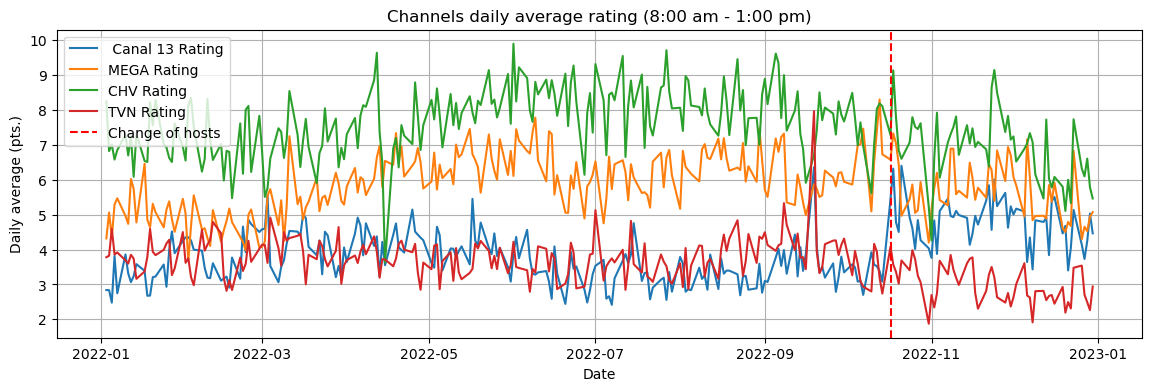

In [88]:
plt.plot(c13["c13"], label=" Canal 13 Rating")
plt.plot(mega["mega"], label="MEGA Rating")
plt.plot(chv["chv"], label="CHV Rating")
plt.plot(tvn["tvn"], label="TVN Rating")
plt.axvline(x=pd.to_datetime('2022-10-17'), color='red', linestyle='--', label='Change of hosts')
plt.legend()
plt.grid()
plt.title("Channels daily average rating (8:00 am - 1:00 pm)")
plt.xlabel("Date")
plt.ylabel("Daily average (pts.)")
plt.savefig("Channels daily average rating.pdf", format="pdf")
plt.show()

All four channels showed very similar trends: no clear patterns or trends, and sharp increases and decreases at very specific times. 

However, following the day the hosts changed, Canal 13 was the only channel that, on average, saw a significant increase in its ratings compared to its competitors. This reinforces the idea that this decision was a success for the company, even though they still failed to position themselves as leaders over the other channels. However, there are many other factors that can explain this behavior beyond who appears on screen. For example, the content aired, the program’s format, and advertising space management, among others.

In [77]:
df[["c13", "mega", "chv", "tvn"]].corr()

,c13,mega,chv,tvn
c13,1.000000,0.224907,0.456471,0.291092
mega,0.224907,1.000000,0.464756,0.325354
chv,0.456471,0.464756,1.000000,0.501629
tvn,0.291092,0.325354,0.501629,1.000000


This suggests that the performance of the channels is not significantly or closely correlated with one another.

## 7. On-Screen Presence Analysis

### 7.1 Rating and Relevant Characters

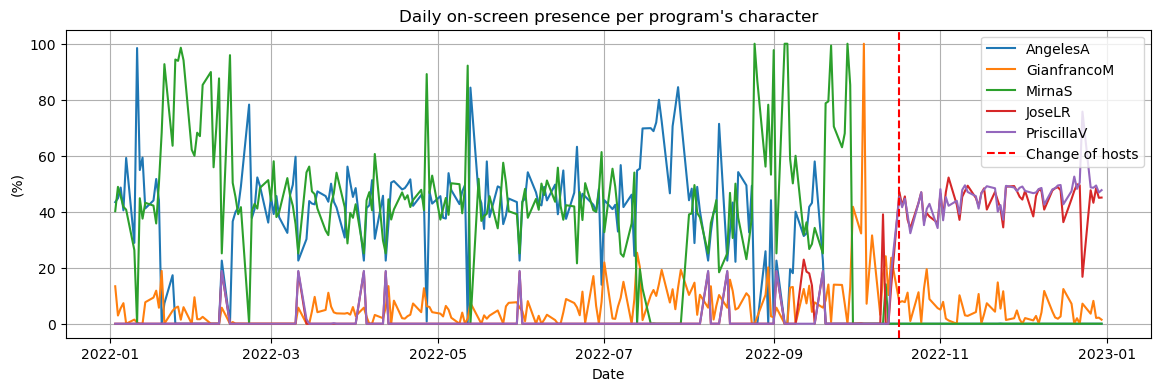

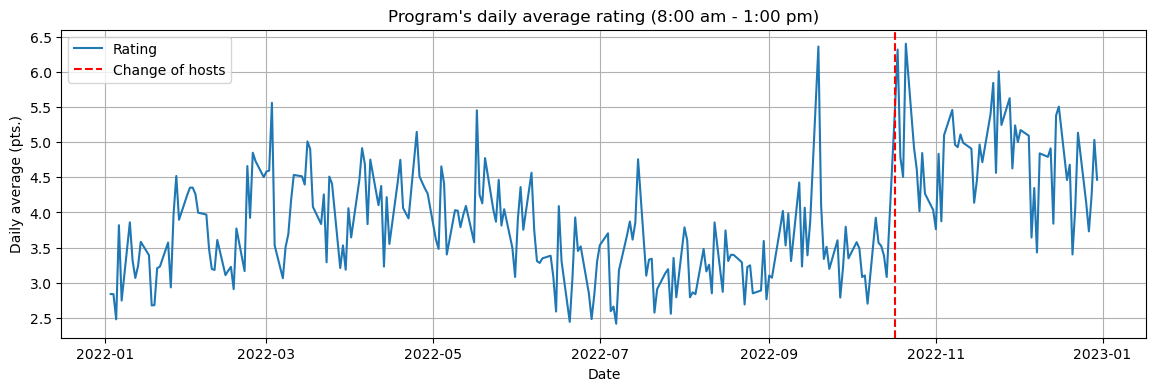

In [90]:
for personaje in personajes_interes:
    sns.lineplot(data=tiempo_rostros, x='Fecha', y=f'{personaje}_porcentaje', label=personaje)
plt.axvline(x=pd.to_datetime('2022-10-17'), color='red', linestyle='--', label='Change of hosts')
plt.title("Daily on-screen presence per program's character")
plt.xlabel('Date')
plt.ylabel('(%)')
plt.grid()
plt.legend()
plt.savefig("On-screen presence per programs's character.pdf", format="pdf")
plt.show()

plt.plot(c13["c13"], label="Rating")
plt.axvline(x=pd.to_datetime('2022-10-17'), color='red', linestyle='--', label='Change of hosts')
plt.legend()
plt.grid()
plt.title("Program's daily average rating (8:00 am - 1:00 pm)")
plt.xlabel("Date")
plt.ylabel("Daily average (pts.)")
plt.show()

The graphs suggested that longer on-screen appearances by Priscilla and José Luis are associated, on average, with a positive increase in the show's audience.

In [79]:
combined_df = pd.concat([c13, tiempo_rostros], axis=1)
combined_df[['c13', 'AngelesA_porcentaje', 'GianfrancoM_porcentaje', 'MirnaS_porcentaje', 'JoseLR_porcentaje', 'PriscillaV_porcentaje']].corr().head(1)

,c13,AngelesA_porcentaje,GianfrancoM_porcentaje,MirnaS_porcentaje,JoseLR_porcentaje,PriscillaV_porcentaje
c13,1.0,-0.346423,-0.159434,-0.292639,0.540191,0.550368


These results suggest that the show’s audience does not appear to be strongly influenced by any of the five characters of interest individually. Although the relationship with José Luis and Priscilla is quite close, it is not significant enough to be taken into account.

### 7.2 Rating and Gender

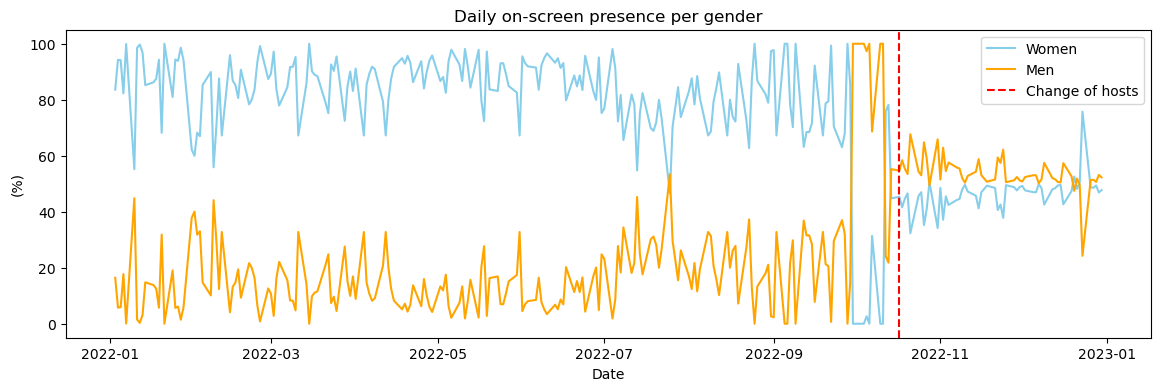

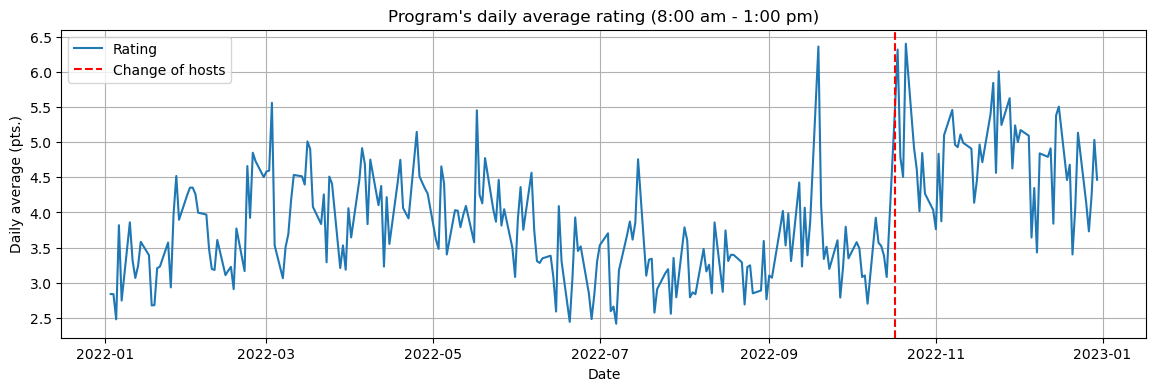

In [91]:
sns.lineplot(data=tiempo_rostros, x='Fecha', y='Porcentaje_Mujeres', label='Women', color='skyblue')
sns.lineplot(data=tiempo_rostros, x='Fecha', y='Porcentaje_Hombres', label='Men', color='orange')
plt.axvline(x=pd.to_datetime('2022-10-17'), color='red', linestyle='--', label='Change of hosts')
plt.title("Daily on-screen presence per gender")
plt.xlabel('Date')
plt.ylabel('(%)')
plt.legend()
plt.savefig("On-screen presence per gender.pdf", format="pdf")
plt.show()

plt.plot(c13["c13"], label="Rating")
plt.axvline(x=pd.to_datetime('2022-10-17'), color='red', linestyle='--', label='Change of hosts')
plt.legend()
plt.grid()
plt.title("Program's daily average rating (8:00 am - 1:00 pm)")
plt.xlabel("Date")
plt.ylabel("Daily average (pts.)")
plt.show()

An analysis of this character segmentation showed that the change in hosts resulted in a fairly clear balance in screen time between men and women. It is important to note that these percentages include everyone who appeared on screen, not just the show’s hosts.

### 7.3 Rating and TV Role

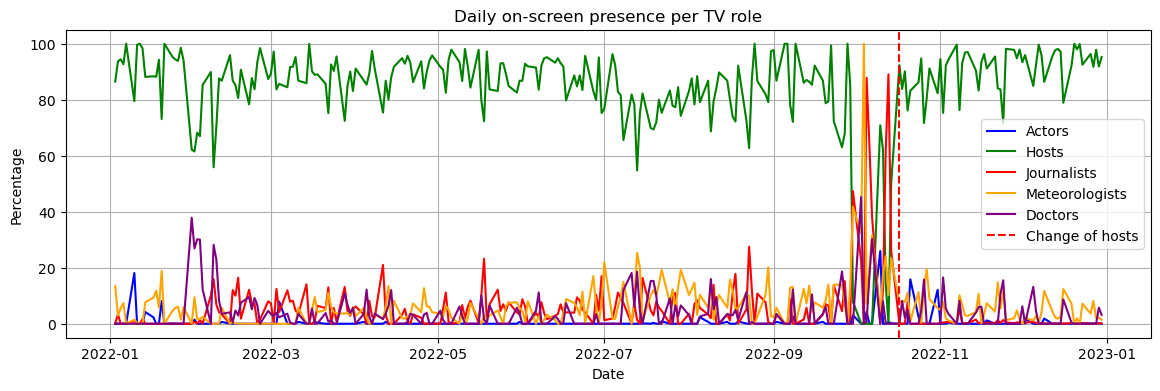

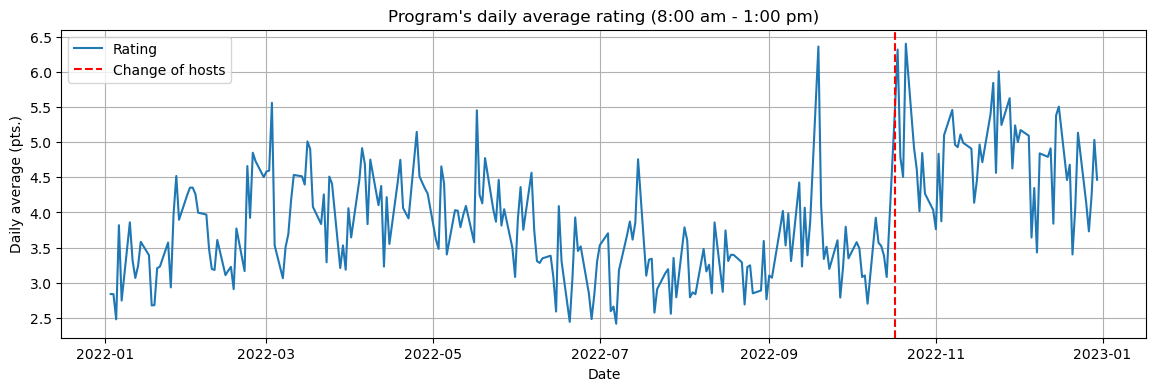

In [92]:
paleta_colores = {
    'Actors': 'blue',
    'Hosts': 'green',
    'Journalists': 'red',
    'Meteorologists': 'orange',
    'Doctors': 'purple'
}

for rol, color in paleta_colores.items():
    sns.lineplot(data=tiempo_rostros, x='Fecha', y=f'Porcentaje_{rol}', label=rol, color=color)
    
plt.axvline(x=pd.to_datetime('2022-10-17'), color='red', linestyle='--', label='Change of hosts')
plt.title('Daily on-screen presence per TV role')
plt.xlabel('Date')
plt.ylabel('Percentage')
plt.grid()
plt.legend()
plt.savefig("On-screen presence per TV role.pdf", format="pdf")
plt.show()

plt.plot(c13["c13"], label="Rating")
plt.axvline(x=pd.to_datetime('2022-10-17'), color='red', linestyle='--', label='Change of hosts')
plt.legend()
plt.grid()
plt.title("Program's daily average rating (8:00 am - 1:00 pm)")
plt.xlabel("Date")
plt.ylabel("Daily average (pts.)")
plt.show()

This analysis showed that there appeared to be a transition period in the days leading up to the official change in hosts. Additionally, it was observed that the amount of screen time allocated to each role did not change significantly after the change took place, suggesting that the program’s increase in viewership is not primarily explained by the segmentation of characters based on their on-screen roles.

### Summary
From this section, the most relevant findings regarding the on-screen presence of television characters can be summarized as follows:

- The increase in on-screen presence of the new hosts is linked to the program’s rise in ratings.
- The change in hosts led to a narrowing of the gap between men’s and women’s screen time.
- Although the data show a transition period prior to the official change date, the characters’ television roles maintained, on average, the same proportions of screen time.

## 8. Forecasting Model

After analyzing several options, it was decided to forecast the last 5 days of 2022; in other words, historical data on ratings and screen time up to December 23, 2022, was used.

### 8.1 Prepare Time Series

In [82]:
#Dataframe with all variables.
series = pd.DataFrame({"c13": c13["c13"],
                       "porcentaje AngelesA": tiempo_rostros["AngelesA_porcentaje"], 
                       "porcentaje GianfrancoM": tiempo_rostros["GianfrancoM_porcentaje"], 
                       "porcentaje MirnaS": tiempo_rostros["MirnaS_porcentaje"], 
                       "porcentaje JoseLR": tiempo_rostros["JoseLR_porcentaje"], 
                       "porcentaje PriscillaV": tiempo_rostros["PriscillaV_porcentaje"], 
                       "porcentaje mujeres": tiempo_rostros["Porcentaje_Mujeres"], 
                       "porcentaje hombres": tiempo_rostros["Porcentaje_Hombres"], 
                       "porcentaje actores": tiempo_rostros["Porcentaje_Actors"],
                       "porcentaje animadores": tiempo_rostros["Porcentaje_Hosts"], 
                       "porcentaje periodistas": tiempo_rostros["Porcentaje_Journalists"], 
                       "porcentaje meteorologos": tiempo_rostros["Porcentaje_Meteorologists"], 
                       "porcentaje doctor": tiempo_rostros["Porcentaje_Doctors"],
                       "mega": mega["mega"],
                       "chv": chv["chv"],
                       "tvn": tvn["tvn"]
                       })

#Train sample that will be used to forecast.
series_train = series[:-5]

#Test sample that will be used to analize model's performance.
series_test = series[-5:]

Before selecting the model, it was necessary to adjust the set of explanatory variables.

#### (a) Elimination of irrelevant variables
Variables that were highly correlated with others or whose variation over time was very low were excluded from the model.

#### (b) Backward variable selection
Through an iterative process using `auto_arima`, variables with negligible statistical significance were removed.

Once this was completed, the model was fitted using the following explanatory variables:

- Daily appearance rate (%) of Priscilla.
- Daily appearance rate (%) of the actors.
- Daily average rating of the TVN channel.

In [83]:
#Fitted model without explanatory variables.
model = ARIMA(series_train["c13"],
              order = (1,0,1),
              seasonal_order=(0,0,0,5)).fit()

#Fitted model with explanatory variables.
new_model = ARIMA(endog=series_train["c13"],
              exog=series_train[["porcentaje PriscillaV", "porcentaje actores", "tvn"]],
              order=(1,0,1),
              seasonal_order=(0,0,0,5)).fit()

### 8.3 Forecast and Evaluate
After identifying temporal patterns, competitor relationships, and on-screen presence effects, the final forecasting model integrates these findings into a predictive framework for audience analysis.

In [84]:
#Model's forecast without explanatory variables.
forecast = model.forecast(5)

#Model's forecast with explanatory variables.
new_forecast = new_model.forecast(steps=5, exog=series_test[["porcentaje PriscillaV", "porcentaje actores", "tvn"]])

In [85]:
#Performance metrics.
mae = mean_absolute_error(series_test["c13"], forecast)
rmse = np.sqrt(mean_squared_error(series_test["c13"], forecast))
absolute_percentage_errors = np.abs((series_test["c13"] - forecast) / series_test["c13"])
absolute_percentage_errors = absolute_percentage_errors[~np.isnan(absolute_percentage_errors)]
mape = np.mean(absolute_percentage_errors) * 100

new_mae = mean_absolute_error(series_test["c13"], new_forecast)
new_rmse = np.sqrt(mean_squared_error(series_test["c13"], new_forecast))
new_absolute_percentage_errors = np.abs((series_test["c13"] - new_forecast) / series_test["c13"])
new_absolute_percentage_errors = new_absolute_percentage_errors[~np.isnan(new_absolute_percentage_errors)]
new_mape = np.mean(new_absolute_percentage_errors) * 100

print("Modelo SIN variables")
print(f"MAE: {mae}")
print(f"MAPE: {mape}")
print(f"RMSE: {rmse}")
print("\nModelo CON variables")
print(f"MAE: {new_mae}")
print(f"MAPE: {new_mape}")
print(f"RMSE: {new_rmse}")

Modelo SIN variables
MAE: 0.391708065230273
MAPE: 9.104499109582315
RMSE: 0.4655523330885908

Modelo CON variables
MAE: 0.3770750333293697
MAPE: 8.815046494139198
RMSE: 0.46632501959945155


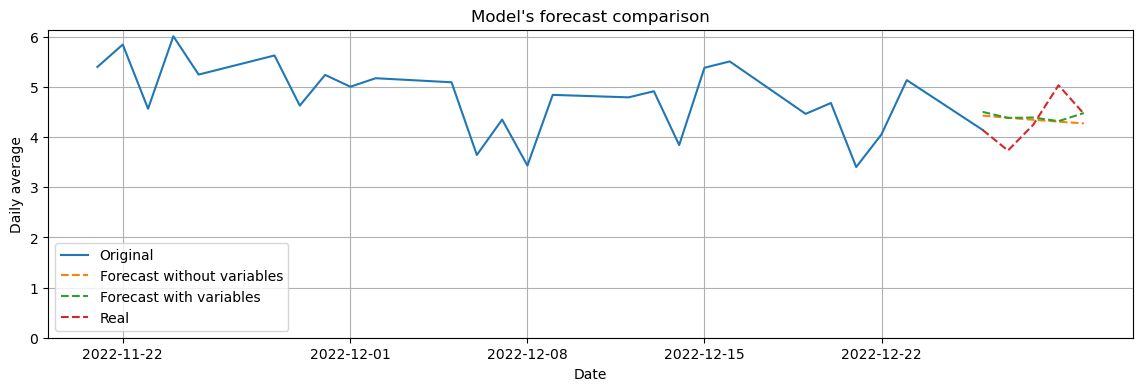

In [93]:
plt.plot(c13["c13"][-30:-4], label="Original")
plt.plot(forecast, label="Forecast without variables", linestyle="--")
plt.plot(new_forecast, label="Forecast with variables", linestyle="--")
plt.plot(series_test["c13"], label="Real", linestyle="--")
plt.legend()
plt.grid()
plt.title("Model's forecast comparison")
plt.xlabel("Date")
plt.ylabel("Daily average")
plt.ylim(bottom=0)
plt.savefig("Model's forecast comparison.pdf", format="pdf")
plt.show()

The model's forecast showed that ratings and their trends are better understood when relevant additional information is included and taken into account. Given that the forecast horizon was short (5 days), this model can assist in the program's short-term planning. However, it should be noted that forecasting errors could be due to factors external to the program that were not included in the analysis (atypical behavior by competitors, unusual events, among others).

## 9. Key Business Insights

Summarize the most important findings in business language.

Example:

1. El rating tiene un aumento significativo posterior a la fecha de cambio de animadores, lo que sugiere que tiene estrecha relación con la incorporación de estos nuevos personajes al programa como animadores.
2. Posterior al cambio, a grandes rasgos la empresa fue la única que aumentó significativamente su rating a comparación de sus competidores. Sin embargo, esto no logra posicionarla como la más vista.
3. La presencia en pantalla se puede analizar tanto individual como en grupos de distinta naturaleza (rostros de mayor interés, género y rol televisivo).
4. La información de la presencia en pantalla ayuda a ajustar y estimar modelo de pronóstico, mejorando su desempeño.
5. Pronósticos de esta naturaleza pueden ayudar en la toma de decisiones del programa en el corto plazo, dado el rango del horizonte de predicción utilizado.

## 10. Business Recommendations

Based on the analysis, the following actions are recommended:

1. Monitor ratings by weekday and time slot to identify recurring audience patterns.
2. Track competitor performance as part of regular programming analysis.
3. Include on-screen presence variables in future audience analysis.
4. Use short-term forecasting as a support tool for programming and content planning.
5. Build a dashboard to make rating performance easier to monitor over time.

## 11. Limitations

The analysis was based on historical data provided by the company, including both ratings and screen time.
At no point was causality assumed regarding the results and findings; instead, data of different types were analyzed to determine whether any correlations existed between them, in line with the overall objective of this study.
The forecasting model is not free from errors, as it is highly likely that factors other than those analyzed influenced the forecast (special event programming, atypical behavior by competitors, unusual national events, among others).

## 12. Next Steps

Potential improvements:

- Add Power BI dashboard for business users
- Include additional external variables like social media
- Compare different forecasting models (more variables groups, other foercast methods, among others)
- Automate weekly reporting
- Expand analysis to longer periods
- Expand analysis to other TV programms within the company

## Author

José Tomás Ahumada  
Data Analyst | Python · SQL · Business Analytics